<a href="https://colab.research.google.com/github/MaheshReddi15/MaheshReddy_machine-learning/blob/main/Object_detection_YOLO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ultralytics opencv-python



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 96.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 79.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 85.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling 

In [2]:
from ultralytics import YOLO
import cv2
import requests
import numpy as np
from google.colab.patches import cv2_imshow



Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


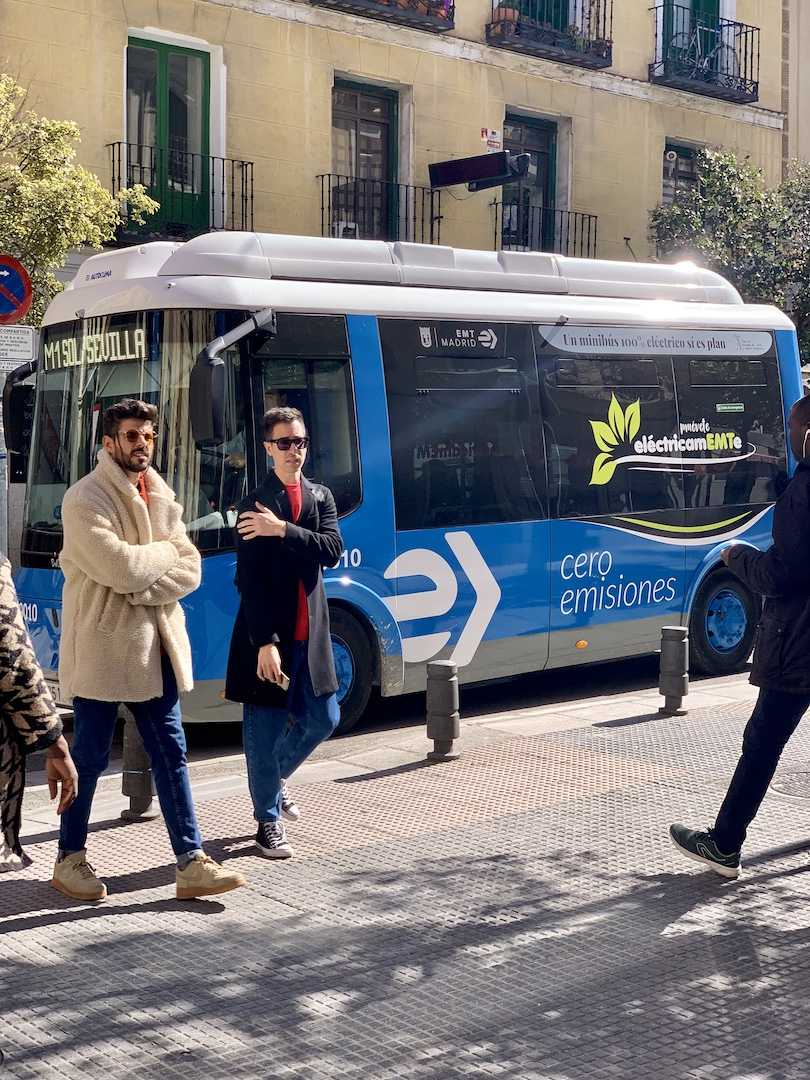

In [3]:
# Download image from Ultralytics demo set
image_url = 'https://ultralytics.com/images/bus.jpg'
response = requests.get(image_url)
img_array = np.asarray(bytearray(response.content), dtype=np.uint8)
image = cv2.imdecode(img_array, cv2.IMREAD_COLOR)

# Save image temporarily
cv2.imwrite("input.jpg", image)
cv2_imshow(image)



image 1/1 /content/input.jpg: 640x480 4 persons, 1 bus, 278.3ms
Speed: 17.0ms preprocess, 278.3ms inference, 3.3ms postprocess per image at shape (1, 3, 640, 480)


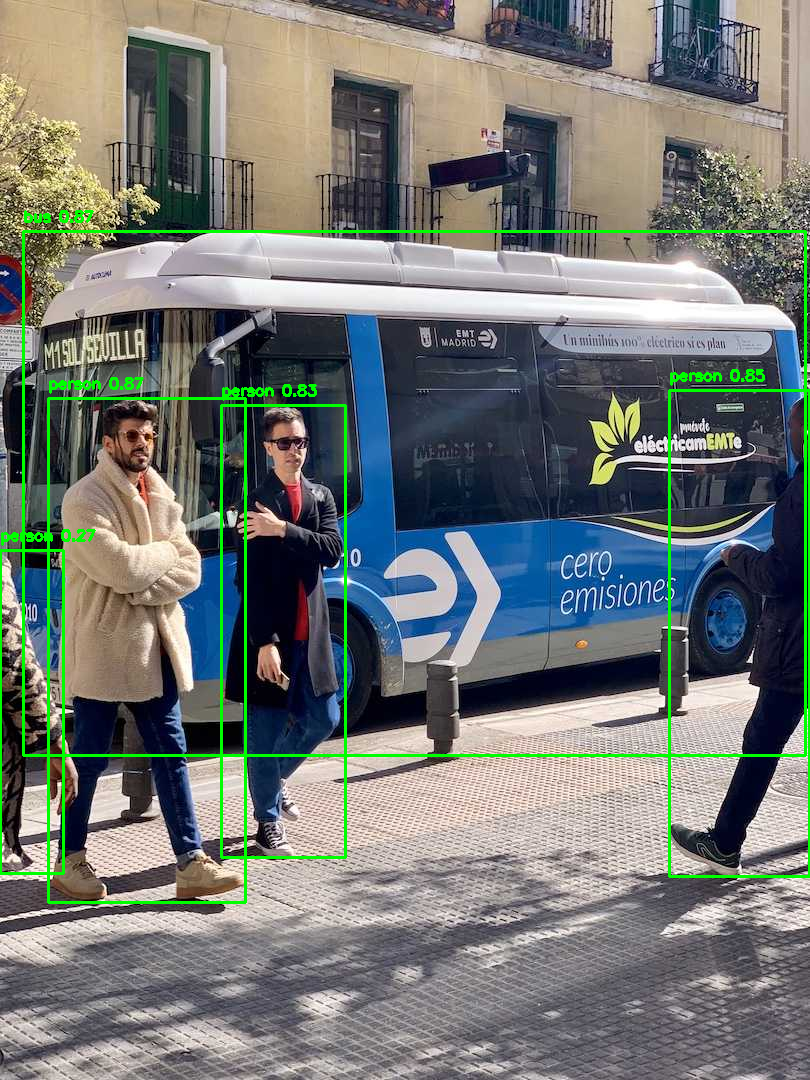

In [8]:
# Load pre-trained YOLOv8n model (nano = lightweight)
model = YOLO('yolov8n.pt')

# Run detection
results = model('input.jpg')

# Get model predictions
image_with_boxes = image.copy()
class_names = model.names

# Loop through detected objects
for box in results[0].boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0])        # box coordinates
    conf = float(box.conf[0])                     # confidence score
    class_id = int(box.cls[0])                    # class ID
    label = f"{class_names[class_id]} {conf:.2f}" # e.g., "person 0.87"

    # Draw box
    cv2.rectangle(image_with_boxes, (x1, y1), (x2, y2), (0, 255, 0), 2)

    # Draw label
    cv2.putText(image_with_boxes, label, (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

# Show result
cv2_imshow(image_with_boxes)

